<a href="https://colab.research.google.com/github/paulmyr/university/blob/master/34_project_course_hpc/5_evaluation/notebooks/jaxley_test_adex_surrogate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use custom jaxley build<br>
-> fork in github.com/paulmyr/jaxley.git

In [73]:
!git clone https://github.com/paulmyr/jaxley.git
!pip install tridiax

import jax
import jax.numpy as jnp
from jax import grad, value_and_grad

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, "/content/jaxley")

import jaxley as jx
from jaxley.channels import AdEx, AdExSurrogate

fatal: destination path 'jaxley' already exists and is not an empty directory.


In [74]:
NAUD_PARAMETERS = {
    "tonic": {
        "C_m": 200,  # pF - Membrane capacitance
        "g_L": 10,  # nS - Leak conductance
        "E_L": -70,  # mV - Leak reversal potential
        "v_T": -50,  # mV - Spike threshold
        "delta_T": 2,  # mV - Spike slope factor
        "v_reset": -58,  # mV - Reset potential (NOT -70!)
        "v_threshold": 0,  # mV - Detection threshold for spike cutoff
        "tau_w": 30,  # ms - Adaptation time constant
        "a": 2,  # nS - Subthreshold adaptation
        "b": 0,  # pA - Spike-triggered adaptation (none for tonic)
        "I": 500,  # pA - Injected Current
    },
    "adaptation": {
        "C_m": 200,  # pF
        "g_L": 12,  # nS - Slightly higher leak
        "E_L": -70,  # mV
        "v_T": -50,  # mV
        "delta_T": 2,  # mV
        "v_reset": -58,  # mV
        "v_threshold": 0,  # mV
        "tau_w": 300,  # ms - 10x slower adaptation!
        "a": 2,  # nS
        "b": 60,  # pA - Strong spike-triggered adaptation
        "I": 500,  # pA - Injected Current
    },
    "original": {
        "C_m": 281,  # pF
        "g_L": 30,  # nS - Slightly higher leak
        "E_L": -70.6,  # mV
        "v_T": -50.4,  # mV
        "delta_T": 2,  # mV
        "v_reset": -70.6,  # mV
        "v_threshold": 20,  # mV
        "tau_w": 144,  # ms - 10x slower adaptation!
        "a": 4,  # nS
        "b": 80.5,  # pA - Strong spike-triggered adaptation
        "I": 2500,  # pA - Injected Current
    },
}

In [75]:
def geometry_for_capacitance(C_pF, specific_capacitance=1.0):
    """Calculate cylindrical cell geometry to achieve target total capacitance."""
    C_uF = C_pF * 1e-6
    area_cm2 = C_uF / specific_capacitance
    radius_cm = np.sqrt(area_cm2 / (6.28 * np.pi))
    radius_um = radius_cm * 1e4
    length_um = 3.14 * radius_um
    return radius_um, length_um, area_cm2


def run_jaxley_adex(params, dt_ms=0.025, duration_ms=400.0, t_max_ms=600.0):
    """
    AdEx simulation in Jaxley.

    Args:
        params: AdEx parameters
        dt_ms: time step in milliseconds
        duration_ms: total time in ms

    Returns:
        time_array, voltage_array, w_array, s_array
    """

    radius_um, length_um, area_cm2 = geometry_for_capacitance(params["C_m"])

    # Create cell with proper geometry
    cell = jx.Cell()
    cell.set("radius", radius_um)
    cell.set("length", length_um)

    # Insert AdEx channel
    cell.insert(AdEx())

    # Set AdEx parameters (convert to density units)
    cell.set("capacitance", params["C_m"])  # μF/cm² (standard)
    cell.set("AdEx_C_m", params["C_m"])  # μF/cm² (standard)
    cell.set("AdEx_g_L", params["g_L"])
    cell.set("AdEx_E_L", params["E_L"])
    cell.set("AdEx_v_T", params["v_T"])
    cell.set("AdEx_delta_T", params["delta_T"])
    cell.set("AdEx_v_threshold", params["v_threshold"])
    cell.set("AdEx_v_reset", params["v_reset"])
    cell.set("AdEx_tau_w", params["tau_w"])
    cell.set("AdEx_a", params["a"])
    cell.set("AdEx_b", params["b"])

    # Set initial conditions
    cell.set("v", params["v_reset"])

    cell.record("v")
    cell.record("AdEx_w")
    cell.record("AdEx_spikes")

    # jx.step_current expects nA
    I_nA = params["I"] * params["C_m"] / 1000.0  # pA -> nA

    # Inject current
    cell.stimulate(jx.step_current(0.0, duration_ms, I_nA, dt_ms, t_max=t_max_ms))

    # Run simulation
    results = jx.integrate(cell, delta_t=dt_ms)

    # Extract results
    voltage_array = np.array(results[0]).flatten()
    w_array = np.array(results[1]).flatten()
    spikes_array = np.array(results[2]).flatten()

    # Create time array with same length as voltage
    time_array = np.arange(len(voltage_array)) * dt_ms

    # Extract spike times
    spike_indices = np.where(spikes_array > 0.5)[0]
    spike_times = time_array[spike_indices] if len(spike_indices) > 0 else np.array([])

    return time_array, voltage_array, w_array, spike_times


def plot_and_run(module, duration=600, t_max=600):
    dt = 0.025

    parameters = NAUD_PARAMETERS[module]

    t_jaxley, v_jaxley, w_jaxley, s_jaxley = run_jaxley_adex(
        parameters, dt_ms=dt, duration_ms=duration, t_max_ms=t_max
    )

    # plt.savefig(f'adex_comparison_{module}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_and_run("tonic")

/content/jaxley/jaxley/channels/non_capacitive/adex.py:87: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


In [76]:
!git clone https://github.com/a1eko/humanspn.git

fatal: destination path 'humanspn' already exists and is not an empty directory.


In [77]:
def rising_edge(data, thresh):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == 1)
    return pos[0][0]


def falling_edge(data, thresh):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == -1)
    return pos[0][0]

In [ ]:
"""
extraction method from

Guarino D, Carannante I, Destexhe A. A unified model library maps how neuromodulation reshapes the excitability landscape of neurons across the brain. PLoS Comput Biol. 2025 Dec 1;21(12):e1013765. doi: 10.1371/journal.pcbi.1013765. PMID: 41325433; PMCID: PMC12680334.

https://github.com/Computational-NeuroPSI/Neuromodulation

"""

import json
import numpy as np


def data_extract_features(
    trace_time,
    trace_voltage,
    stim_delay,
    stim_duration,
    # curr,
    dt,
):

    results = []
    time = trace_time

    freq = None
    inv_first_ISI = None
    inv_last_ISI = None
    time_to_first_spike = None
    time_to_second_spike = None
    time_to_third_spike = None
    time_to_last_spike = None
    volt_stimend = None

    # current = curr #pA
    current = None

    ### checking spikes ###
    peak_index = []
    for i in range(1, len(trace_voltage)):
        if trace_voltage[i] > 10 and trace_voltage[i - 1] < 10:
            peak_index.append(i)

    freq = len(peak_index) / (stim_duration / 1e3)
    if len(peak_index) > 0:
        time_to_first_spike = time[peak_index[0]] - stim_delay  # ms
    if len(peak_index) >= 2:
        inv_first_ISI = 1e3 / ((time[peak_index[1]] - time[peak_index[0]]))  # Hz
        time_to_second_spike = time[peak_index[1]] - stim_delay  # ms
    if len(peak_index) >= 3:
        inv_second_ISI = 1e3 / ((time[peak_index[1]] - time[peak_index[0]]))  # Hz
        time_to_third_spike = time[peak_index[2]] - stim_delay  # ms
    if len(peak_index) > 3:
        time_to_last_spike = time[peak_index[-1]] - stim_delay  # ms
        inv_last_ISI = 1e3 / ((time[peak_index[-1]] - time[peak_index[-2]]))  # Hz

    # if last spike arrives before half of the stim_duration, we also compute the volt_stimend
    if time_to_last_spike < stim_duration / 2:
        index_end_stim = int((stim_delay + stim_duration) / dt)
        volt_stimend = np.mean(
            trace_voltage[index_end_stim - int(30 / dt) : index_end_stim]
        )

    results.append(
        (
            current,
            freq,
            inv_first_ISI,
            inv_last_ISI,
            time_to_first_spike,
            time_to_second_spike,
            time_to_third_spike,
            time_to_last_spike,
            volt_stimend,
        )
    )

    return results


IDthresh_543.soma.i
IDthresh_543.soma.v

            Frequency: 3.5 Hz
            Inverse first ISI: 8.81 Hz
            Inverse last ISI: 3.39 Hz
            Time to first spike: 245.9 ms
            Time to second spike: 359.4 ms
            Time to third spike: 482.1 ms
            Time to last spike: 1440.8 ms
            Steady state voltage stim end: N/A mV
            
IDthresh_544.soma.i
IDthresh_544.soma.v

            Frequency: 6.0 Hz
            Inverse first ISI: 12.06 Hz
            Inverse last ISI: 2.02 Hz
            Time to first spike: 124.5 ms
            Time to second spike: 207.4 ms
            Time to third spike: 304.8 ms
            Time to last spike: 1980.4 ms
            Steady state voltage stim end: N/A mV
            
IDthresh_553.soma.i
IDthresh_553.soma.v

            Frequency: 23.0 Hz
            Inverse first ISI: 27.1 Hz
            Inverse last ISI: 23.87 Hz
            Time to first spike: 35.2 ms
            Time to second spike: 72.1 ms
     

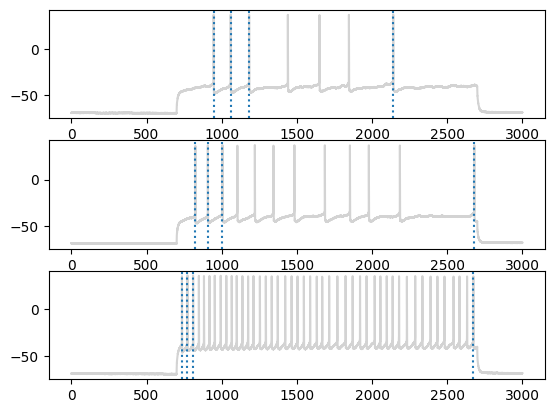

In [78]:
def read_data(path, expdata, junction_potential=0):
    BASEPATH = f"./humanspn/models/optimisations/{path}/"
    fig, axes = plt.subplots(len(expdata) // 2, figsize=None)
    for i, expname in enumerate(expdata.keys()):
        index = i // 2
        print(expname)
        data = np.loadtxt(BASEPATH + expdata[expname])
        time = data[:, 0]
        dt = time[1] - time[0]

        if expname[-1] == "i":
            current = data[:, 1] - junction_potential

            stim_delay = time[rising_edge(current, 100)]
            stim_end = time[falling_edge(current, 100)]
            stim_duration = stim_end - stim_delay

        if expname[-1] == "v":
            voltage = data[:, 1] - junction_potential

            axes[index].plot(time, voltage, "-", color="lightgrey")

            features = data_extract_features(
                time, voltage, stim_delay, stim_duration, dt
            )

            # Extract values
            freq = round(features[0][1], 2)
            inv_first_ISI = round(features[0][2], 2)
            inv_last_ISI = round(features[0][3], 2)
            time_to_first_spike = round(features[0][4], 2)
            time_to_second_spike = round(features[0][5], 2)
            time_to_third_spike = round(features[0][6], 2)
            time_to_last_spike = round(features[0][7], 2)
            volt_stimend = (
                round(features[0][8], 2) if features[0][8] is not None else None
            )

            print(f"""
            Frequency: {freq} Hz
            Inverse first ISI: {inv_first_ISI} Hz
            Inverse last ISI: {inv_last_ISI} Hz
            Time to first spike: {time_to_first_spike} ms
            Time to second spike: {time_to_second_spike} ms
            Time to third spike: {time_to_third_spike} ms
            Time to last spike: {time_to_last_spike} ms
            Steady state voltage stim end: {f"{round(volt_stimend, 2)}" if volt_stimend is not None else "N/A"} mV
            """)

            axes[index].axvline(x=time_to_first_spike + stim_delay, ls=":")
            axes[index].axvline(x=time_to_second_spike + stim_delay, ls=":")
            axes[index].axvline(x=time_to_third_spike + stim_delay, ls=":")
            axes[index].axvline(x=time_to_last_spike + stim_delay, ls=":")

    plt.show()


data = {
    "mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/": {
        #'IV_499.soma.i': 'expdata/ECBL_IV_ch4_499.dat',
        #'IV_499.soma.v': 'expdata/ECBL_IV_ch5_499.dat',
        #'IV_502.soma.i': 'expdata/ECBL_IV_ch4_502.dat',
        #'IV_502.soma.v': 'expdata/ECBL_IV_ch5_502.dat',
        #'IDthresh-sub_541.soma.i': 'expdata/ECBL_IDthresh_ch4_541.dat',
        #'IDthresh-sub_541.soma.v': 'expdata/ECBL_IDthresh_ch5_541.dat',
        "IDthresh_543.soma.i": "expdata/ECBL_IDthresh_ch4_543.dat",
        "IDthresh_543.soma.v": "expdata/ECBL_IDthresh_ch5_543.dat",
        "IDthresh_544.soma.i": "expdata/ECBL_IDthresh_ch4_544.dat",
        "IDthresh_544.soma.v": "expdata/ECBL_IDthresh_ch5_544.dat",
        "IDthresh_553.soma.i": "expdata/ECBL_IDthresh_ch4_553.dat",
        "IDthresh_553.soma.v": "expdata/ECBL_IDthresh_ch5_553.dat",
    }
}

print()

for path in data.keys():
    read_data(path, data[path])

In [79]:
"""
Loss function from:

Guarino D, Carannante I, Destexhe A. A unified model library maps how neuromodulation reshapes the excitability landscape of neurons across the brain. PLoS Comput Biol. 2025 Dec 1;21(12):e1013765. doi: 10.1371/journal.pcbi.1013765. PMID: 41325433; PMCID: PMC12680334.

https://github.com/Computational-NeuroPSI/Neuromodulation

"""


# Computing the relative error.
def compute_error(
    data_current,
    indices_sup,
    data_freq,
    model_freq,
    data_volt_stimend,
    model_volt_stimend,
    data_inv_first_ISI,
    model_inv_first_ISI,
    data_inv_last_ISI,
    model_inv_last_ISI,
    data_time_to_first_spike,
    model_time_to_first_spike,
    data_time_to_second_spike,
    model_time_to_second_spike,
    data_time_to_third_spike,
    model_time_to_third_spike,
    data_time_to_last_spike,
    model_time_to_last_spike,
):
    err = np.zeros((num_samples, len(data_current)))
    err_tot = np.zeros(num_samples)

    # Definig the weight of each feature
    # Default value is 1
    w_freq = 1
    w_first_spike = 1
    w_second_spike = 1
    w_inv_first_ISI = 1
    w_third_spike = 1
    w_last_spike = 1
    w_inv_last_ISI = 1

    for i in range(0, num_samples):
        for j in range(0, len(data_current)):
            if abs(data_freq[j]) != 0:
                ### adding relative error freq

                err[i, j] = (
                    abs((abs(data_freq[j]) - abs(model_freq[i, j])) / abs(data_freq[j]))
                ) * w_freq

                if math.isnan(model_time_to_first_spike[i, j]):
                    err[i, j] = err[i, j] + 3
                else:
                    time_to_first_spike_diff = (
                        abs(
                            data_time_to_first_spike[j]
                            - model_time_to_first_spike[i, j]
                        )
                        / data_time_to_first_spike[j]
                    ) * w_first_spike
                    ### adding relative error time_to_first_spike
                    err[i, j] = err[i, j] + time_to_first_spike_diff
                if abs(data_freq[j]) > 1:
                    if math.isnan(model_inv_first_ISI[i, j]):
                        err[i, j] = err[i, j] + 3
                    else:
                        inv_first_ISI_diff = (
                            abs(
                                abs(data_inv_first_ISI[j])
                                - abs(model_inv_first_ISI[i, j])
                            )
                            / abs(data_inv_first_ISI[j])
                        ) * w_inv_first_ISI
                        ### adding relative error inv_first_ISI
                        err[i, j] = err[i, j] + inv_first_ISI_diff
                    if math.isnan(model_time_to_second_spike[i, j]):
                        err[i, j] = err[i, j] + 3
                    else:
                        time_to_second_spike_diff = (
                            abs(
                                data_time_to_second_spike[j]
                                - model_time_to_second_spike[i, j]
                            )
                            / data_time_to_second_spike[j]
                        ) * w_second_spike
                        ### adding relative error time_to_second_spike
                        err[i, j] = err[i, j] + time_to_second_spike_diff
                if abs(data_freq[j]) > 2:
                    if math.isnan(model_inv_last_ISI[i, j]):
                        err[i, j] = err[i, j] + 3
                    else:
                        inv_last_ISI_diff = (
                            abs(
                                abs(data_inv_last_ISI[j])
                                - abs(model_inv_last_ISI[i, j])
                            )
                            / abs(data_inv_last_ISI[j])
                        ) * w_inv_last_ISI
                        ### adding relative error inv_last_ISI
                        err[i, j] = err[i, j] + inv_last_ISI_diff
                    if math.isnan(model_time_to_third_spike[i, j]):
                        err[i, j] = err[i, j] + 3
                    else:
                        time_to_third_spike_diff = (
                            abs(
                                data_time_to_third_spike[j]
                                - model_time_to_third_spike[i, j]
                            )
                            / data_time_to_third_spike[j]
                        ) * w_third_spike
                        ### adding relative error time_to_third_spike
                        err[i, j] = err[i, j] + time_to_third_spike_diff
                    if math.isnan(model_time_to_last_spike[i, j]):
                        err[i, j] = err[i, j] + 3
                    else:
                        time_to_last_spike_diff = (
                            abs(
                                data_time_to_last_spike[j]
                                - model_time_to_last_spike[i, j]
                            )
                            / data_time_to_last_spike[j]
                        ) * w_last_spike
                        ### adding relative error time_to_last_spike
                        err[i, j] = err[i, j] + time_to_last_spike_diff
            else:
                ### adding error freq
                err[i, j] = abs(abs(data_freq[j]) - abs(model_freq[i, j]))

        err_tot[i] = np.sum(err[i])

    return err, err_tot